## **Praktikum Pengolahan Sinyal Digital 2**



---



* Nama: Raka Muhammad Al Hafidz
* NIM: 241344087
* Kelas: 2C-TNK


## Modul 11: FIR Filter dan IIR Filter (Soft Filtering)

## FIR Filter

In [1]:
import numpy as np
from scipy.signal import firwin, freqz
import matplotlib.pyplot as plt



> firwin doc : https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.firwin.html



Filternya tidak langsung meng-cutoff secara tajam, tidak ujug2 nol kek yg pas di Trans. Fourier

### Lowpass - Hamming Window FIR

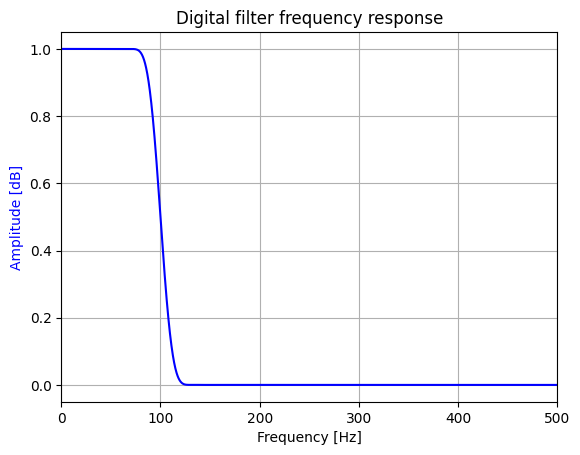

In [2]:
fs = 1000 # Frekuensi sampling (sampling frequency)
cutoff = 100 # Freq. yang ingin dipotong (cutoff)
trans_width = 100 # Seberapa miring filternya (transisi dari passband ke stopband)
numtaps = 101 # Panjang filter (jumlah koefisien)

taps = firwin(numtaps, cutoff, window='blackman', pass_zero=True, fs=fs)
#window menentukan koefisien filter, pass_zero=True untuk lowpass filter, fs untuk normalisasi frekuensi cutoff
#blackman adalah jenis window yang digunakan untuk mengurangi efek samping seperti sidelobe pada filter FIR
#hamming, hanning, dan bartlett adalah jenis window lainnya yang juga dapat digunakan untuk desain filter FIR
#rectangular window menghasilkan filter dengan sidelobe yang lebih tinggi, sedangkan blackman window menghasilkan filter dengan sidelobe yang lebih rendah

#window = rectangle/hamming/hanning/blackman
#pass_zero = True/False (lowpass/highpass)

w, h = freqz(taps, 1, worN=2000)

fig, ax1 = plt.subplots()
ax1.set_title('Digital filter frequency response')
ax1.plot(0.5*fs*w/np.pi, np.abs(h), 'b')
ax1.set_ylabel('Amplitude [dB]', color='b')
ax1.set_xlabel('Frequency [Hz]')
ax1.set_ylim([-0.05, 1.05])
ax1.set_xlim([0, 0.5*fs])
ax1.grid()

plt.show()

[ 1.08192282e-34 -1.35855822e-06 -9.01414109e-06 -2.08586736e-05
 -2.36424739e-05  7.16701129e-20  5.71022038e-05  1.30806087e-04
  1.78120639e-04  1.45558863e-04 -3.13502513e-19 -2.38584181e-04
 -4.82272663e-04 -5.94830668e-04 -4.48486722e-04  7.90413026e-19
  6.49450779e-04  1.24993221e-03  1.47686284e-03  1.07197491e-03
 -1.56521920e-18 -1.45512303e-03 -2.72369571e-03 -3.13760298e-03
 -2.22520467e-03  2.65066568e-18  2.90012038e-03  5.33287792e-03
  6.04489108e-03  4.22506250e-03 -3.97433903e-18 -5.37390359e-03
 -9.78620207e-03 -1.10049630e-02 -7.64562023e-03  5.37283125e-18
  9.67157734e-03  1.76334636e-02  1.99166624e-02  1.39510183e-02
 -6.62066011e-18 -1.82149362e-02 -3.40946088e-02 -3.99334515e-02
 -2.94109503e-02  7.48617855e-18  4.55752887e-02  9.94462098e-02
  1.50382960e-01  1.86788809e-01  1.99993122e-01  1.86788809e-01
  1.50382960e-01  9.94462098e-02  4.55752887e-02  7.48617855e-18
 -2.94109503e-02 -3.99334515e-02 -3.40946088e-02 -1.82149362e-02
 -6.62066011e-18  1.39510

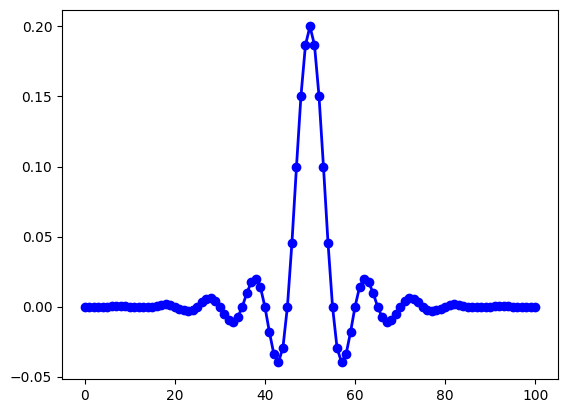

In [3]:
print(taps)
plt.plot(taps, 'bo-', linewidth=2)

## IIR Filter - Highpass butterworth filter

Finite Impulse Response = FIR

Infinite Impluse Response = IIR



> scipyt butterworth - https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html



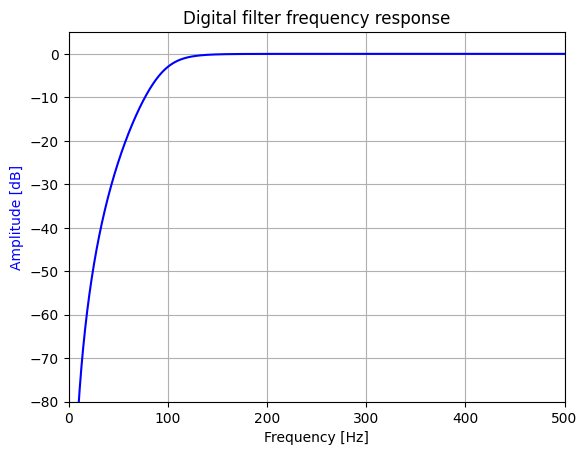

In [ ]:
import numpy as np
from scipy.signal import butter, freqz, filtfilt
import matplotlib.pyplot as plt


fs = 1000
cutoff = 100
order = 4


b, a = butter(order, cutoff/(0.5*fs), btype='high')
#bytype = high untuk highpass filter, low untuk lowpass filter, bandpass untuk bandpass filter, bandstop untuk bandstop filter
#b = numerator
#a = donumerator

#kalau ingin melakukan filter terhadap sinyal, gunakan filtfilt untuk menghindari distorsi fase
# filtered_signal = filtfilt(b, a, input_signal)
w, h = freqz(b, a, worN=2000)

fig, ax1 = plt.subplots()
ax1.set_title('Digital filter frequency response')
ax1.plot(0.5*fs*w/np.pi, 20*np.log10(np.abs(h)), 'b')
ax1.set_ylabel('Amplitude [dB]', color='b')
ax1.set_xlabel('Frequency [Hz]')
ax1.set_ylim([-80, 5])
ax1.set_xlim([0, 0.5*fs])
ax1.grid()

plt.show()

## Pertanyaan
1. Dari kode diatas coba modifikasi FIR untuk:
- BPF Blackman Window
- BPF Rectangular Window
- LPF Hanning Window
- HPF Hanning Window
- Band Stop Filter Hamming Window
- Band Stop Filter Hanning Window

BPF Blackman Window

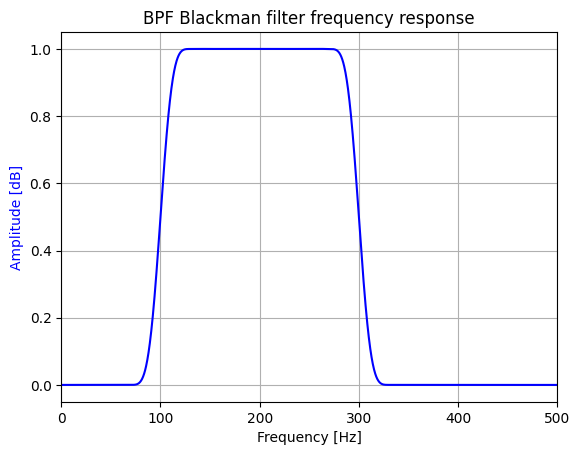

In [23]:
fs = 1000 # Frekuensi sampling (sampling frequency)
lowcut = 100 # Freq. yang ingin dipotong (cutoff [lowcut dan highcut untuk bandpass filter])
highcut = 300
trans_width = 100 # Seberapa miring filternya (transisi dari passband ke stopband)
numtaps = 101 # Panjang filter (jumlah koefisien)

taps = firwin(numtaps, [lowcut, highcut], window='blackman', pass_zero=False, fs=fs)

w, h = freqz(taps, 1, worN=2000)

plt.plot(0.5*fs*w/np.pi, np.abs(h), 'b')
plt.title('BPF Blackman filter frequency response')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude [dB]', color='b')
plt.ylim([-0.05, 1.05])
plt.xlim([0, 0.5*fs])
plt.grid()
plt.show()

BPF Rectangular Window

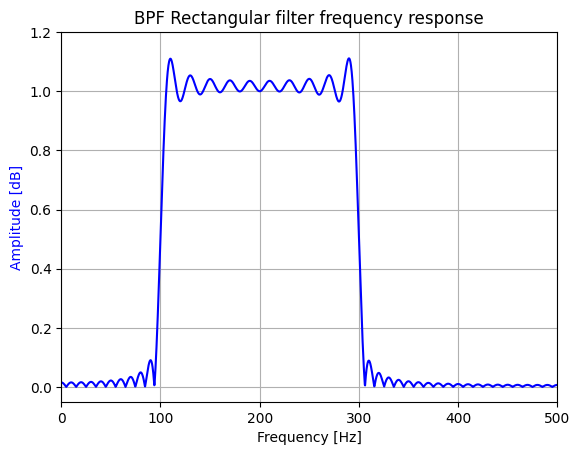

In [24]:
fs = 1000 # Frekuensi sampling (sampling frequency)
lowcut = 100 # Freq. yang ingin dipotong (cutoff [lowcut dan highcut untuk bandpass filter])
highcut = 300
trans_width = 100 # Seberapa miring filternya (transisi dari passband ke stopband)
numtaps = 101 # Panjang filter (jumlah koefisien)

taps = firwin(numtaps, [lowcut, highcut], window='rectangular', pass_zero=False, fs=fs)

w, h = freqz(taps, 1, worN=2000)

plt.plot(0.5*fs*w/np.pi, np.abs(h), 'b')
plt.title('BPF Rectangular filter frequency response')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude [dB]', color='b')
plt.ylim([-0.05, 1.2])
plt.xlim([0, 0.5*fs])
plt.grid()
plt.show()

LPF Hanning Window

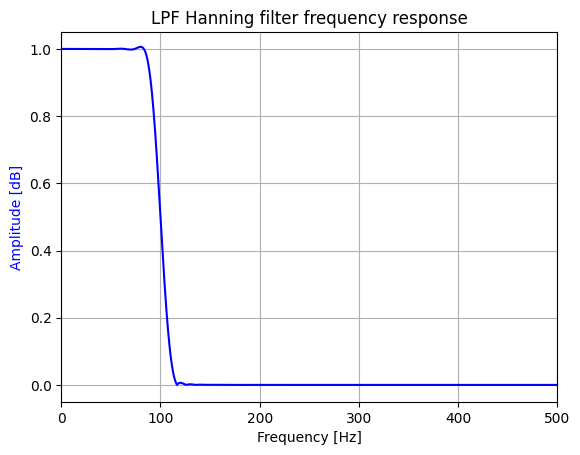

In [25]:
fs = 1000 # Frekuensi sampling (sampling frequency)
cutoff = 100 # Freq. yang ingin dipotong (cutoff)
trans_width = 100 # Seberapa miring filternya (transisi dari passband ke stopband)
numtaps = 101 # Panjang filter (jumlah koefisien)

taps = firwin(numtaps, cutoff, window='hann', pass_zero=True, fs=fs)

w, h = freqz(taps, 1, worN=2000)

plt.plot(0.5*fs*w/np.pi, np.abs(h), 'b')
plt.title('LPF Hanning filter frequency response')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude [dB]', color='b')
plt.ylim([-0.05, 1.05])
plt.xlim([0, 0.5*fs])
plt.grid()
plt.show()

HPF Hanning Window

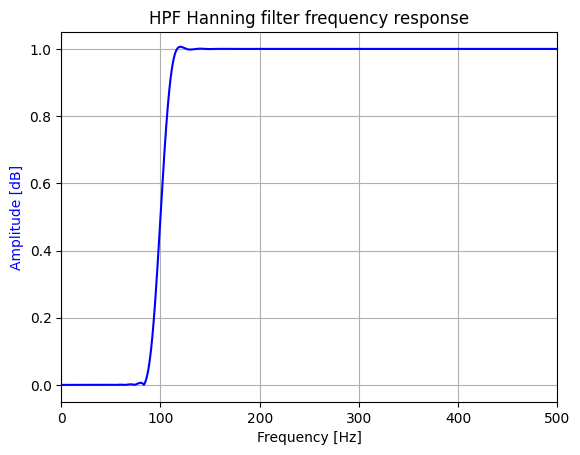

In [26]:
fs = 1000 # Frekuensi sampling (sampling frequency)
cutoff = 100 # Freq. yang ingin dipotong (cutoff)
trans_width = 100 # Seberapa miring filternya (transisi dari passband ke stopband)
numtaps = 101 # Panjang filter (jumlah koefisien)

taps = firwin(numtaps, cutoff, window='hann', pass_zero=False, fs=fs)

w, h = freqz(taps, 1, worN=2000)

plt.plot(0.5*fs*w/np.pi, np.abs(h), 'b')
plt.title('HPF Hanning filter frequency response')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude [dB]', color='b')
plt.ylim([-0.05, 1.05])
plt.xlim([0, 0.5*fs])
plt.grid()
plt.show()

Band Stop Filter Hamming Window

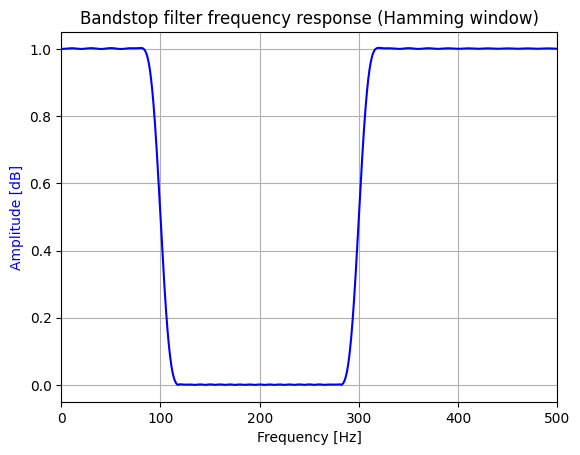

In [3]:
fs = 1000 # Frekuensi sampling (sampling frequency)
lowcut = 100 # Freq. yang ingin dipotong (cutoff [lowcut dan highcut untuk bandpass filter])
highcut = 300
trans_width = 100 # Seberapa miring filternya (transisi dari passband ke stopband)
numtaps = 101 # Panjang filter (jumlah koefisien)

taps = firwin(numtaps, [lowcut, highcut], window='hamming', pass_zero=True, fs=fs)

w, h = freqz(taps, 1, worN=2000)

plt.plot(0.5*fs*w/np.pi, np.abs(h), 'b')
plt.title('Bandstop filter frequency response (Hamming window)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude [dB]', color='b')
plt.ylim([-0.05, 1.05])
plt.xlim([0, 0.5*fs])
plt.grid()
plt.show()

Band Stop Filter Hanning Window

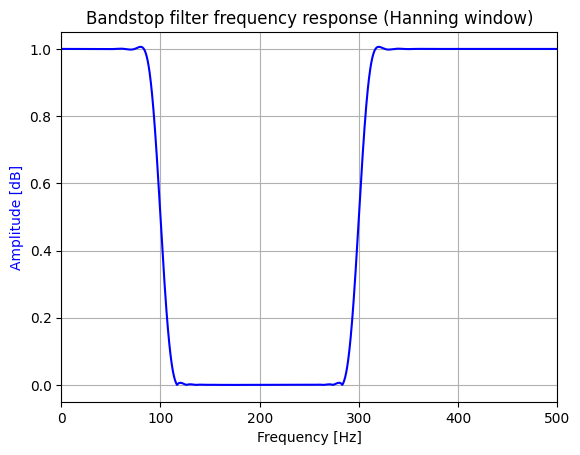

In [4]:
fs = 1000 # Frekuensi sampling (sampling frequency)
lowcut = 100 # Freq. yang ingin dipotong (cutoff [lowcut dan highcut untuk bandpass filter])
highcut = 300
trans_width = 100 # Seberapa miring filternya (transisi dari passband ke stopband)
numtaps = 101 # Panjang filter (jumlah koefisien)

taps = firwin(numtaps, [lowcut, highcut], window='hann', pass_zero=True, fs=fs)

w, h = freqz(taps, 1, worN=2000)

plt.plot(0.5*fs*w/np.pi, np.abs(h), 'b')
plt.title('Bandstop filter frequency response (Hanning window)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude [dB]', color='b')
plt.ylim([-0.05, 1.05])
plt.xlim([0, 0.5*fs])
plt.grid()
plt.show()

2. Apa kira-kira perbedaan masing-masing window?


Sebelumnya, kita bahas dulu mengapa kita butuh Window, secara teori matematis, filter FIR yang "ideal" (misalnya filter lowpass yang memotong frekuensi secara instan) membutuhkan jumlah tap (panjang filter) yang tak terhingga. Karena kita harus memotong panjang filter ini menjadi terbatas (sepanjang $N$; atau disini disebut `numtaps`), pemotongan mendadak ini menyebabkan Fenomena Gibbs — munculnya riak (ripple) atau gelombang yang tidak diinginkan pada respons frekuensi. Untuk mengurangi riak ini, kita mengalikan filter dengan sebuah Fungsi Window.

Penggunaan window selalu melibatkan pertukaran antara dua hal:
Lebar Pita Transisi (Main Lobe): Seberapa tajam filter berubah dari melewatkan ke menahan frekuensi.
Redaman Stopband (Side Lobe): Seberapa bersih filter membuang frekuensi yang tidak diinginkan (diukur dalam dB).

Perbedaan dari masing-masing window adalah:

>1. Rectangular: Tidak ada pelandaian sama sekali (semua bobot bernilai 1). Ini sama saja dengan memotong filter secara kasar. Terlihat pada gambar yang menggunakan window Rectangular. Menghasilkan pita transisi yang sangat tajam dan tidak se-*smooth* yang lain. Bisa dilihat dari gambar bahwa di sekitar frekuensi 100 Hz dan 300 Hz, grafik langsung naik/turun secara sangat curam, hampir seperti garis tegak lurus.

>2. Blackman ("blackman"): Frekuensi luar benar-benar teredam bersih, tapi area cutoff menjadi sangat tumpul/gradual. Butuh $N$ yang sangat besar jika ingin tajam. Bisa dilihat dari gambar (BPF) bahwa area passband 100–300 Hz garisnya benar-benar rata sempurna di angka 1.0, paling rata dibanding semua gambar lain.

>3. Hanning ("hann"): transisi dua kali lebih lebar dari Rectangular (kurang tajam), tetapi redamannya jauh lebih baik (sekitar $-31$ dB). Untuk membuat transisinya lebih tajam, lebarkan atau besarkan numtaps

>4. Hamming ("hamming"): Bisa dilihat dari gambar (Bandstop) bahwa transisinya mulus tanpa riak, mirip seperti Hanning (LPF), tapi sedikit lebih tegas di pinggirnya.


## Percobaan

3. Buat suatu sinyal kotak dengan frekuensi sampling 10 kHz, durasi 0.1 detik, frekuensi sinyal 50.

In [1]:
import numpy as np
from scipy.signal import square, firwin, freqz, butter, filtfilt
import matplotlib.pyplot as plt

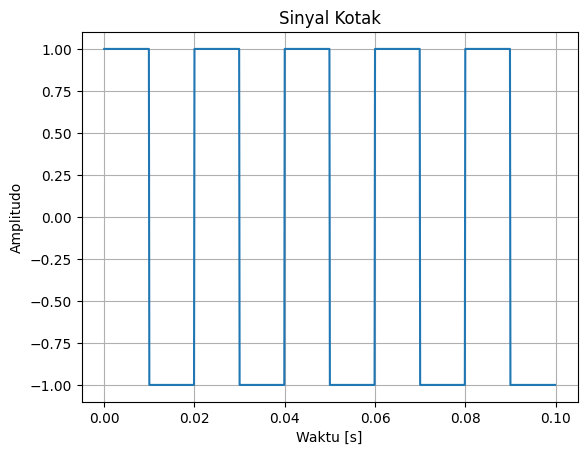

In [2]:
# Sinyal kotak:
# signal.square()
fs = 10000
dur = 10**-1
freq = 50

t = np.linspace(0, dur, int(fs*dur), endpoint=False)
signal = square(2 * np.pi * freq * t)

plt.plot(t, signal)
plt.title('Sinyal Kotak')
plt.xlabel('Waktu [s]')
plt.ylabel('Amplitudo')
plt.grid()
plt.show()

4. Buat suatu koefisien low pass FIR filter dengan frekuensi cutoff 500 Hz panjang filter 101, dengan window Hamming. Lalu konvolusikan dengan sinyal kotak yang dibuat sebelumnya (mode konvolusi, mode='same')


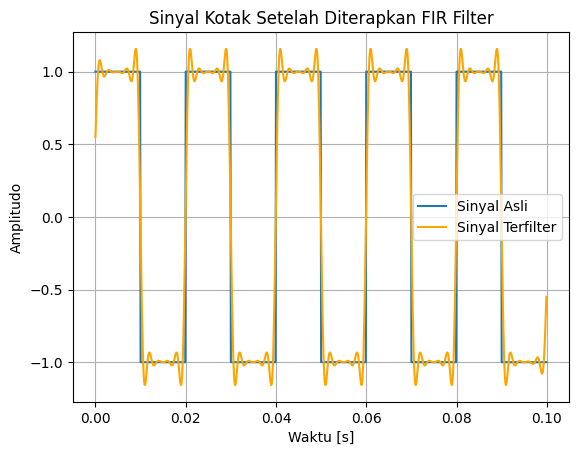

In [3]:
cutoff = 500 # Freq. yang ingin dipotong (cutoff)
trans_width = 100 # Seberapa miring filternya (transisi dari passband ke stopband)
numtaps = 101 # Panjang filter (jumlah koefisien)

taps = firwin(numtaps, cutoff, window='hamming', pass_zero=True, fs=fs)

filtered_signal_fir = np.convolve(signal, taps, mode='same')

plt.plot(t, signal, label='Sinyal Asli')
plt.plot(t, filtered_signal_fir, label='Sinyal Terfilter', color='orange')
plt.title('Sinyal Kotak Setelah Diterapkan FIR Filter')
plt.xlabel('Waktu [s]')
plt.ylabel('Amplitudo')
plt.legend()
plt.grid()
plt.show()

5. Buat juga filter dengan menggunakan IIR filter - butterworth order 4, dengan cutoff yang sama

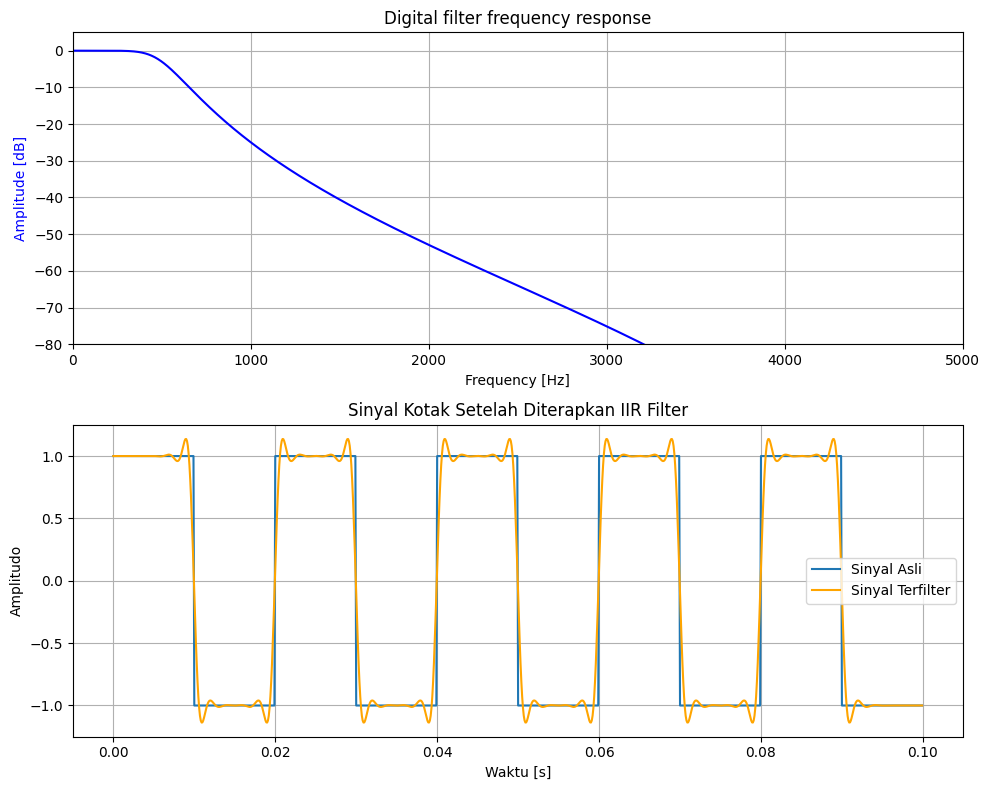

In [ ]:
cutoff = 500
order = 4

b, a = butter(order, cutoff/(0.5*fs), btype='low')
#bytype = high untuk highpass filter, low untuk lowpass filter, bandpass untuk bandpass filter, bandstop untuk bandstop filter
#b = numerator
#a = donumerator

#kalau ingin melakukan filter terhadap sinyal, gunakan filtfilt untuk menghindari distorsi fase
# filtered_signal = filtfilt(b, a, input_signal)
w, h = freqz(b, a, worN=2000)

filtered_signal_iir = filtfilt(b, a, signal)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].set_title('Digital filter frequency response')
axes[0].plot(0.5*fs*w/np.pi, 20*np.log10(np.abs(h)), 'b')
axes[0].set_ylabel('Amplitude [dB]', color='b')
axes[0].set_xlabel('Frequency [Hz]')
axes[0].set_ylim([-80, 5])
axes[0].set_xlim([0, 0.5*fs])

axes[0].grid()

axes[1].plot(t, signal, label='Sinyal Asli')
axes[1].plot(t, filtered_signal_iir, label='Sinyal Terfilter', color='orange')
axes[1].set_title('Sinyal Kotak Setelah Diterapkan IIR Filter')
axes[1].set_xlabel('Waktu [s]')
axes[1].set_ylabel('Amplitudo')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

6. Lakukan juga lowpass filter dengan menggunakan FFT. Bandingkan ketiga hasil di domain frekuensi dan juga di domain waktu.

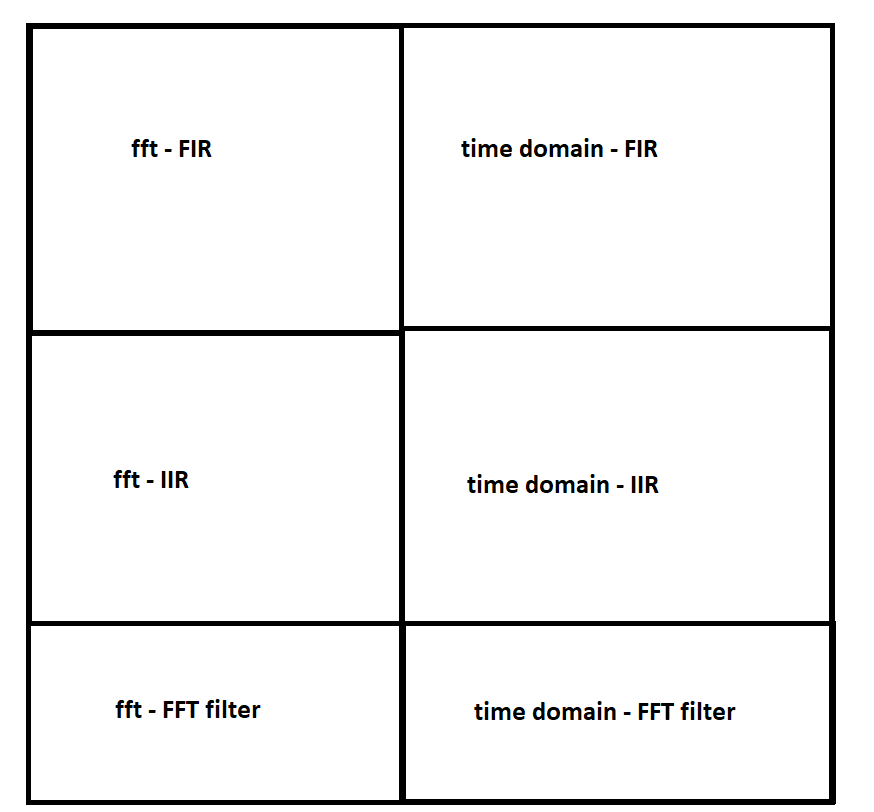

/Users/raka/Materi Kuliah/PSD 2/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/raka/Materi Kuliah/PSD 2/.venv/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


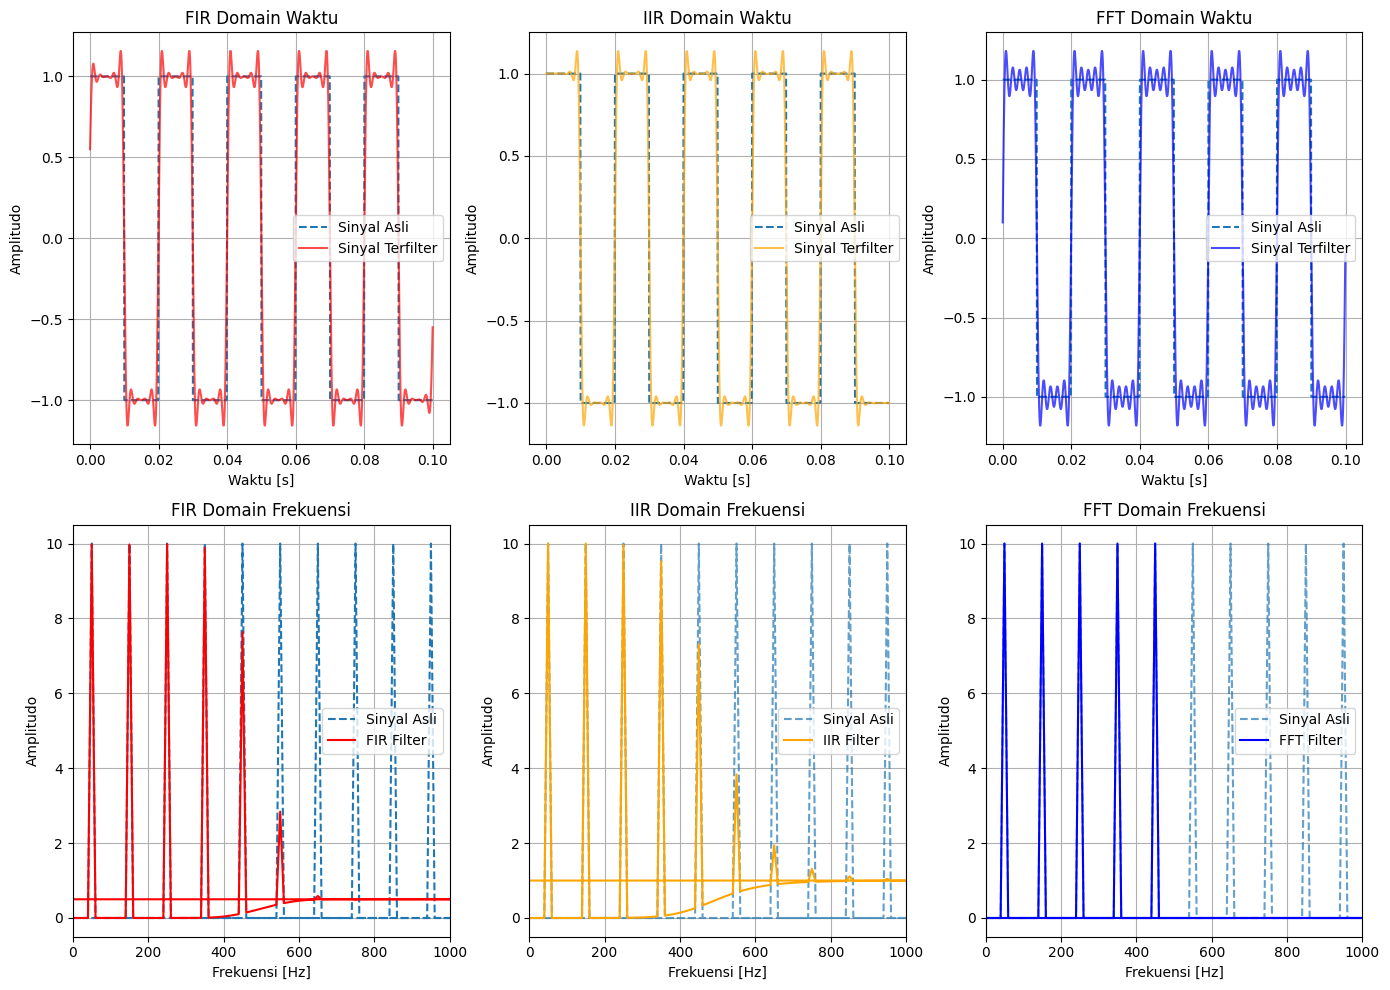

In [ ]:
signal_length = len(signal)
fft_signal = np.fft.fft(signal)
frequencies = np.fft.fftfreq(signal_length, d=1/fs)

fig, axes = plt.subplots(2, 3, figsize=(14, 10))

#FFT filter time domain
fft_signal_square = np.fft.fft(signal)
freq = np.fft.fftfreq(signal_length, 1/fs)
signal_fft_hard = np.copy(fft_signal_square)
signal_fft_hard[np.abs(freq) > cutoff] = 0
filtered_signal_fft = np.fft.ifft(signal_fft_hard)

fft_fir = np.fft.fft(filtered_signal_fir)
fft_iir = np.fft.fft(filtered_signal_iir)

axes[0, 0].plot(t, signal, label='Sinyal Asli', linestyle='--')
axes[0, 0].plot(t, filtered_signal_fir, label='Sinyal Terfilter', color='red', alpha=0.7)
axes[0, 0].set_title('FIR Domain Waktu')
axes[0, 0].set_xlabel('Waktu [s]')
axes[0, 0].set_ylabel('Amplitudo')
axes[0, 0].legend()
axes[0, 0].grid()

axes[0, 1].plot(t, signal, label='Sinyal Asli', linestyle='--')
axes[0, 1].plot(t, filtered_signal_iir, label='Sinyal Terfilter', color='orange', alpha=0.7)
axes[0, 1].set_title('IIR Domain Waktu')
axes[0, 1].set_xlabel('Waktu [s]')
axes[0, 1].set_ylabel('Amplitudo')
axes[0, 1].legend()
axes[0, 1].grid()

axes[0, 2].plot(t, signal, label='Sinyal Asli', linestyle='--')
axes[0, 2].plot(t, filtered_signal_fft.real, label='Sinyal Terfilter', color='blue', alpha=0.7)
axes[0, 2].set_title('FFT Domain Waktu')
axes[0, 2].set_xlabel('Waktu [s]')
axes[0, 2].set_ylabel('Amplitudo')
axes[0, 2].legend()
axes[0, 2].grid()

axes[1, 0].plot(frequencies, fft_signal, label='Sinyal Asli', linestyle='--')
axes[1, 0].plot(frequencies, fft_fir, label='FIR Filter', color='red')
axes[1, 0].set_title('FIR Domain Frekuensi')
axes[1, 0].set_xlabel('Frekuensi [Hz]')
axes[1, 0].set_ylabel('Amplitudo')
axes[1, 0].set_xlim([0, 1000])
axes[1, 0].legend()
axes[1, 0].grid()

axes[1, 1].plot(frequencies, fft_signal, label='Sinyal Asli', linestyle='--', alpha=0.7)
axes[1, 1].plot(frequencies, fft_iir, label='IIR Filter', color='orange')
axes[1, 1].set_title('IIR Domain Frekuensi')
axes[1, 1].set_xlabel('Frekuensi [Hz]')
axes[1, 1].set_ylabel('Amplitudo')
axes[1, 1].set_xlim([0, 1000])
axes[1, 1].legend()
axes[1, 1].grid()

axes[1, 2].plot(frequencies, fft_signal, label='Sinyal Asli', linestyle='--', alpha=0.7)
axes[1, 2].plot(frequencies, signal_fft_hard, label='FFT Filter', color='blue')
axes[1, 2].set_title('FFT Domain Frekuensi')
axes[1, 2].set_xlabel('Frekuensi [Hz]')
axes[1, 2].set_ylabel('Amplitudo')
axes[1, 2].set_xlim([0, 1000])
axes[1, 2].legend()
axes[1, 2].grid()


plt.tight_layout()
plt.show()


7. Dari hasil, apa perbedaan dari masing-masing filter

Gambar di atas menunjukkan 6 grafik: 3 grafik atas menunjukkan domain waktunya, sedangkan 3 grafik bawah menunjukkan grafik domain frekuensinya.

FIR:
> Untuk domain waktunya, bisa dilihat dari gambar bahwa sinyal terfilter (merah) hampir mengikuti sinyal asli, tapi di bagian tepi yang naik/turun ada riak kecil (ringing). Bagian datar sinyal cukup bersih.

> Bisa dilihat dari gambar bahwa beberapa frekuensi diblokir dengan cukup tajam (ada spike-spike yang tersisa di sekitar 100–400 Hz), lalu turun drastis setelahnya. Tapi transisinya tidak sempurna mulus.

IIR:
Bedanya dari FIR: bahwa output sebelumnya diumpanbalikkan (feedbackloop) ke dalam perhitungan. Seperti filter yang "mengingat" outputnya sendiri
> Untuk domain waktunya, bisa dilihat dari gambar bahwa di bagian transisi naik/turun ada overshoot (sinyal sempat melewati batas 1.0 atau -1.0 sebentar sebelum stabil). Ini efek dari feedback loop tadi.

> Untuk domain frekuensinya, Bisa dilihat dari gambar bahwa responnya lebih landai/gradual — tidak ada spike tajam, melainkan kurva yang naik perlahan dari 0 sampai ~1.0. Ini menunjukkan IIR tidak se-presisi FIR dalam memotong frekuensi tertentu, tapi lebih smooth.

FFT:
> Untuk domain waktunya, bisa dilihat dari gambar bahwa ripple/riak terjadi di seluruh bagian sinyal (tidak hanya di tepi, tapi juga di bagian datar yang harusnya lurus). Ini paling "berantakan" di domain waktu.

> Untuk domain frekuensinya, bisa dilihat dari gambar bahwa hanya frekuensi tertentu saja yang diloloskan (tampak sebagai garis-garis tegak yang sangat tipis dan presisi). Frekuensi lain benar-benar = 0. Paling tajam dari ketiga metode.